In [38]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [39]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixs: int
    
    sr: float # strike rate
    bpb: float # balls per boundary
    boundary_percentage: float
    summary: str

In [40]:
def calc_sr(state: BatsmanState) -> BatsmanState:
    sr = (state['runs'] / state['balls']) * 100
    return {'sr' : sr}

In [41]:
def calc_bpb(state: BatsmanState) -> BatsmanState:
    bpb = state['balls'] / (state['fours'] + state['sixs'])
    return {'bpb': bpb}

In [42]:
def calc_boundary_percentage(state: BatsmanState) -> BatsmanState:
    bp = (((state['fours'] * 4) + (state['sixs'] * 6)) / state['runs']) * 100
    return {'boundary_percentage' : bp}

In [43]:
def summary(state: BatsmanState) -> BatsmanState:
    summary = f'''
    Strike Rate -> {state['sr']} \n
    Balls per Boundary -> {state['bpb']} \n
    Boundary Percentage -> {state['boundary_percentage']} \n
    '''
    return {'summary' : summary}

In [44]:
graph = StateGraph(BatsmanState)

graph.add_node('calc_sr', calc_sr)
graph.add_node('calc_bpb', calc_bpb)
graph.add_node('calc_boundary_percentage', calc_boundary_percentage)
graph.add_node('summary', summary)

graph.add_edge(START, 'calc_sr')
graph.add_edge(START, 'calc_bpb')
graph.add_edge(START, 'calc_boundary_percentage')

graph.add_edge('calc_boundary_percentage', 'summary')
graph.add_edge('calc_sr', 'summary')
graph.add_edge('calc_bpb', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

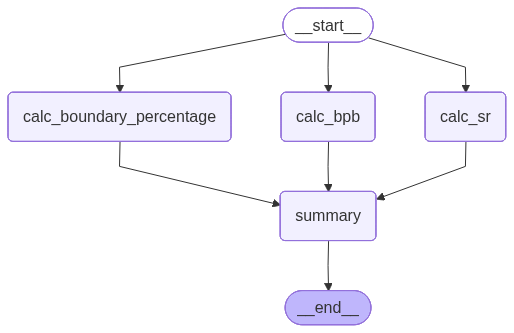

In [45]:
workflow

In [46]:
initial_state = {
    "runs": 80,
    "balls": 50,
    "fours": 8,
    "sixs": 2,
}

final_state = workflow.invoke(initial_state)

In [47]:
print(final_state)

{'runs': 80, 'balls': 50, 'fours': 8, 'sixs': 2, 'sr': 160.0, 'bpb': 5.0, 'boundary_percentage': 55.00000000000001, 'summary': '\n    Strike Rate -> 160.0 \n\n    Balls per Boundary -> 5.0 \n\n    Boundary Percentage -> 55.00000000000001 \n\n    '}
